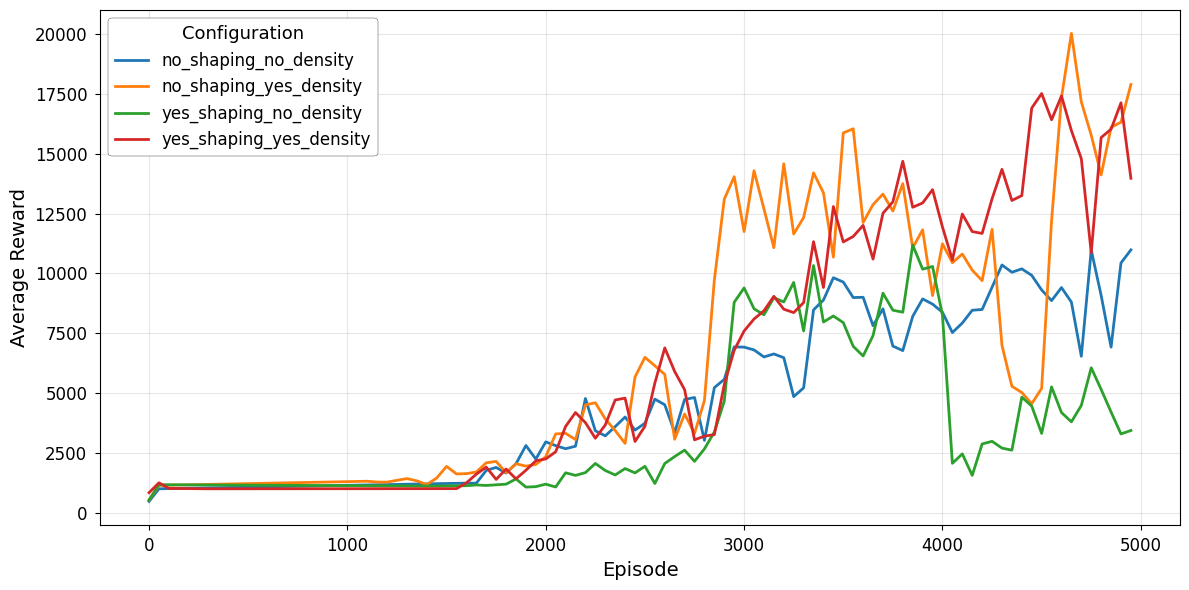

Rilevate 4 sessioni di allenamento nel file.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

file_path = r'C:\Users\user\Documents\UNI\TESI\confronti_trainign_dqn\arkanoid.txt'

# 1. Parsing del file con rilevamento nuove sessioni
sessions = []
current_session_data = []
# Nomi personalizzati per le 4 sessioni (modificali in base ai tuoi test)
session_names = ["no_shaping_no_density", "no_shaping_yes_density", "yes_shaping_no_density", "yes_shaping_yes_density"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blu, Arancio, Verde, Rosso

pattern = re.compile(r"\[Ep\s+(?P<ep>\d+)\] ε=(?P<eps>[\d.]+) \| R:\s+(?P<r>[\d.-]+) \(avg (?P<r_avg>[\d.-]+)\) \| Survived:\s+(?P<surv>[\d.]+)s \(avg\s+(?P<surv_avg>[\d.]+)s\)")

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                ep = int(match.group('ep'))
                
                # Se l'episodio è 0 e abbiamo già dati, significa che è iniziato un nuovo allenamento
                if ep == 0 and current_session_data:
                    sessions.append(pd.DataFrame(current_session_data))
                    current_session_data = []
                
                d = match.groupdict()
                current_session_data.append({
                    'Episodio': ep,
                    'Reward_Media': float(d['r_avg']),
                    'Sopravvivenza_Media': float(d['surv_avg'])
                })
        
        # Aggiungi l'ultima sessione rimasta nel buffer
        if current_session_data:
            sessions.append(pd.DataFrame(current_session_data))

# 2. Creazione dei Grafici
if not sessions:
    print("Nessun dato trovato. Verifica il formato del file.")
else:
    plt.style.use('seaborn-v0_8-paper')
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

    for i, df in enumerate(sessions):
        label = session_names[i] if i < len(session_names) else f"Training {i+1}"
        color = colors[i] if i < len(colors) else None
        
        # Plot Reward
        ax1.plot(df['Episodio'], df['Reward_Media'], label=label, color=color, linewidth=2)
        # Plot Sopravvivenza
        # ax2.plot(df['Episodio'], df['Sopravvivenza_Media'], label=label, color=color, linewidth=2)

    # Styling Reward
    # ax1.set_title('Confronto Reward Media (4 Allenamenti)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Average Reward', fontsize=14)
    ax1.set_xlabel('Episode', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    # ax1.legend(title="Configurazioni", loc='best', frameon=True, fontsize=12, title_fontsize=13)
    ax1.legend(title="Configuration", loc='best', frameon=True, fontsize=12, title_fontsize=13, edgecolor='black', framealpha=1.0)
    ax1.grid(True, alpha=0.3)

    # Styling Sopravvivenza
    # ax2.set_title('Confronto Tempo di Sopravvivenza Medio', fontsize=14, fontweight='bold')
    # ax2.set_ylabel('Secondi (avg)')
    # ax2.set_xlabel('Episodi')
    # ax2.legend(title="Configurazioni", loc='best', frameon=True)
    # ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    print(f"Rilevate {len(sessions)} sessioni di allenamento nel file.")